# Video Game Market Segmentation: Data Preprocessing
## Enhanced Feature Engineering Pipeline

**Author:** Data Science Team  
**Date:** January 2026  
**Version:** 2.0  

---

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading and Exploration](#2-data-loading)
3. [Data Cleaning](#3-data-cleaning)
4. [Feature Engineering - Core Features](#4-core-features)
5. [Feature Engineering - Genre Features](#5-genre-features)
6. [Feature Engineering - Platform Features](#6-platform-features)
7. [Feature Engineering - Interaction Features](#7-interaction-features)
8. [Outlier Detection and Removal](#8-outlier-removal)
9. [Feature Scaling and Normalization](#9-scaling)
10. [Feature Validation and Export](#10-export)

---

## Objective
This notebook prepares video game sales data for clustering analysis by:
- Engineering 40+ features from raw data
- Creating scale-invariant ratio features
- Encoding categorical variables (genre, platform)
- Handling outliers systematically
- Scaling features appropriately for clustering algorithms

## Methodology
We employ a comprehensive feature engineering approach that transforms raw sales data into 
meaningful clustering features while preserving market structure information.

---
## 1. Environment Setup

### 1.1 Import Required Libraries

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
# Preprocessing
from sklearn.preprocessing import RobustScaler

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Environment setup complete.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Environment setup complete.
Pandas version: 2.3.3
NumPy version: 1.26.4


---
## 2. Data Loading and Exploration

### 2.1 Load Raw Data

**Expected columns:**
- Sales: `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, `Global_Sales`
- Quality: `Critic_Score`, `User_Score`
- Categorical: `Genre`, `Platform`, `Publisher`, `Year`

In [2]:
# Load data 

dataset_path = kagglehub.dataset_download("asaniczka/video-game-sales-2024")
csv_file = [f for f in os.listdir(dataset_path) if f.endswith('.csv')][0]

df_raw = pd.read_csv(os.path.join(dataset_path, csv_file))

print("Data loaded successfully.")
print(f"Dataset shape: {df_raw.shape}")
print(f"Total records: {len(df_raw):,}")
df_raw.head()

Data loaded successfully.
Dataset shape: (64016, 14)
Total records: 64,016


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4000,20.3200,6.3700,0.9900,9.8500,3.1200,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7000,19.3900,6.0600,0.6000,9.7100,3.0200,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6000,16.1500,8.4100,0.4700,5.4900,1.7800,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.8600,9.0600,0.0600,5.3300,1.4200,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1000,15.0900,6.1800,0.4100,6.0500,2.4400,2015-11-06,2018-01-14


### 2.2 Initial Data Exploration

In [3]:
# Display basic information
print("Dataset Information:")
print("="*80)
print(df_raw.info())
print("\nColumn Names:")
print(df_raw.columns.tolist())
print("\nFirst 5 Records:")
print(df_raw.head())
print("\nBasic Statistics:")
print(df_raw.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB
None

Column Names:
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_

### 2.3 Missing Value Analysis

Missing Values Summary:
              Missing_Count  Missing_Percent
critic_score          57338          89.5682
jp_sales              57290          89.4933
na_sales              51379          80.2596
pal_sales             51192          79.9675
other_sales           48888          76.3684
last_update           46137          72.0710
total_sales           45094          70.4418
release_date           7051          11.0144
developer                17           0.0266


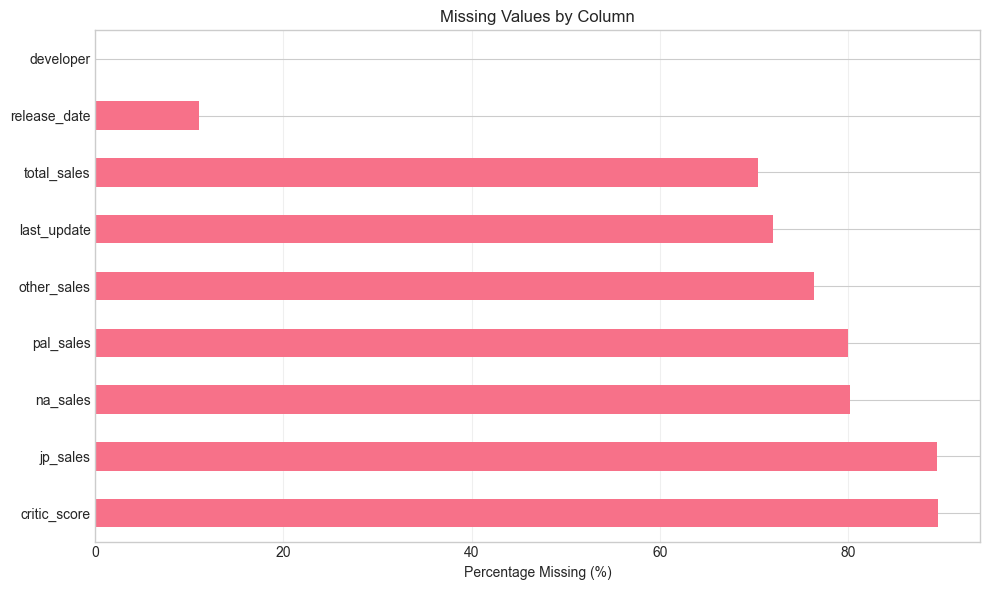

In [4]:
# Calculate missing values
missing_values = df_raw.isnull().sum()
missing_percent = (missing_values / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
}).sort_values('Missing_Percent', ascending=False)

print("Missing Values Summary:")
print("="*80)
print(missing_df[missing_df['Missing_Count'] > 0])

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_df[missing_df['Missing_Count'] > 0]['Missing_Percent'].plot(kind='barh', ax=ax)
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Missing Values by Column')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning

### 3.1 Remove Records with Missing Critical Values

**Rationale:** Games missing sales data, genre, or platform cannot be meaningfully clustered.

In [37]:
# Store original size
original_size = len(df_raw)

# Remove records with missing critical values (correct column names)
df = df_raw.dropna(subset=['total_sales', 'genre', 'console']).copy()

print(f"Records removed: {original_size - len(df):,}")
print(f"Remaining records: {len(df):,}")
print(f"Retention rate: {len(df)/original_size*100:.2f}%")


Records removed: 45,094
Remaining records: 18,922
Retention rate: 29.56%


### 3.2 Handle Missing Quality Scores

**Strategy:** Impute with median to preserve distribution.

In [38]:
# Handle Critic_Score
if 'Critic_Score' in df.columns:
    critic_median = df['Critic_Score'].median()
    missing_critic = df['Critic_Score'].isnull().sum()
    df['Critic_Score'] = df['Critic_Score'].fillna(critic_median)
    print(f"Imputed {missing_critic} missing Critic_Score values with median: {critic_median}")

# Handle User_Score
if 'User_Score' in df.columns:
    df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')
    user_median = df['User_Score'].median()
    missing_user = df['User_Score'].isnull().sum()
    df['User_Score'] = df['User_Score'].fillna(user_median)
    print(f"Imputed {missing_user} missing User_Score values with median: {user_median}")

# Handle Year
if 'Year' in df.columns:
    year_median = df['Year'].median()
    missing_year = df['Year'].isnull().sum()
    df['Year'] = df['Year'].fillna(year_median)
    print(f"Imputed {missing_year} missing Year values with median: {year_median}")

### 3.3 Filter Commercial Games

**Threshold:** Minimum $0.05M in global sales  
**Rationale:** Exclude non-commercial or data entry errors.

In [7]:
# Apply sales threshold
pre_filter_size = len(df)
SALES_THRESHOLD = 0.05

df = df[df['total_sales'] >= SALES_THRESHOLD].copy()

print(f"Sales threshold applied: ${SALES_THRESHOLD}M")
print(f"Records removed: {pre_filter_size - len(df):,}")
print(f"Commercial games retained: {len(df):,}")
print(f"Final retention from original: {len(df)/original_size*100:.2f}%")

Sales threshold applied: $0.05M
Records removed: 5,655
Commercial games retained: 13,267
Final retention from original: 20.72%


### 3.4 Store Original Categorical Columns

**Purpose:** Preserve original values for analysis and profiling.

In [8]:
# Create copies of original categorical variables
df['genre_original'] = df['genre']
df['console_original'] = df['console']
df['publisher_original'] = df['publisher']

if "Year" not in df.columns:
    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df["Year"] = df["release_date"].dt.year

df['year_original'] = df['Year']

print("Original categorical columns preserved.")

print("\nGenre distribution (top 10):")
print(df['genre'].value_counts().head(10))

print("\nConsole distribution (top 10):")
print(df['console'].value_counts().head(10))


Original categorical columns preserved.

Genre distribution (top 10):
genre
Sports          2145
Action          2134
Misc            1359
Shooter         1139
Role-Playing    1070
Racing          1060
Adventure        916
Platform         760
Fighting         720
Simulation       720
Name: count, dtype: int64

Console distribution (top 10):
console
PS2     1722
DS      1550
PS3     1105
X360    1104
Wii     1074
PS      1014
PSP      749
XB       682
PS4      631
GBA      630
Name: count, dtype: int64


---
## 4. Feature Engineering - Core Features

### 4.1 Sales Absolute Features (5 features)

**Description:** Direct sales values in millions of dollars.  
**Purpose:** Capture magnitude of commercial success.

In [9]:
# Create sales features
df['total_sales'] = df['total_sales']
df['na_sales'] = df['na_sales']
df['jp_sales'] = df['jp_sales']
df['pal_sales'] =df['pal_sales']
df['other_sales'] = df['other_sales']

sales_features = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']

print("Sales Features Created (5):")
print(df[sales_features].describe())

Sales Features Created (5):
       total_sales   na_sales  jp_sales  pal_sales  other_sales
count   13267.0000 10880.0000 4487.0000 10046.0000   11719.0000
mean        0.4906     0.3047    0.1441     0.1888       0.0554
std         0.9289     0.5223    0.1934     0.4355       0.1415
min         0.0500     0.0000    0.0000     0.0000       0.0000
25%         0.1100     0.0700    0.0400     0.0200       0.0100
50%         0.2200     0.1400    0.0800     0.0600       0.0200
75%         0.5100     0.3200    0.1700     0.1800       0.0500
max        20.3200     9.7600    2.1300     9.8500       3.1200


### 4.2 Quality Metrics (2 features)

**Description:** Product quality and market timing indicators.  
**Variables:**
- `critic_score`: Normalized critic rating (0-10 scale)
- `game_age`: Years since release (temporal feature)

In [10]:
# Normalize critic score to 0-10 scale
df['critic_score'] = df['critic_score'] / 10.0

# Calculate game age
CURRENT_YEAR = 2025
df['game_age'] = CURRENT_YEAR - df['Year']

quality_features = ['critic_score', 'game_age']

print("Quality Features Created (2):")
print(df[quality_features].describe())

Quality Features Created (2):
       critic_score   game_age
count     3634.0000 13242.0000
mean         0.7146    18.0463
std          0.1404     6.2225
min          0.1000     5.0000
25%          0.6400    14.0000
50%          0.7400    17.0000
75%          0.8200    22.0000
max          1.0000    48.0000


### 4.3 Market Structure Features (5 features)

**Description:** Scale-invariant regional sales patterns.  
**Key Metric:** Herfindahl-Hirschman Index (HHI) for market concentration.

**HHI Interpretation:**
- HHI < 0.5: Balanced global sales
- HHI > 0.7: Concentrated in one region

In [11]:
# Calculate regional sales ratios
# Small constant prevents division by zero
EPSILON = 0.001

df['na_sales_ratio'] = df['na_sales'] / (df['total_sales'] + EPSILON)
df['jp_sales_ratio'] = df['jp_sales'] / (df['total_sales'] + EPSILON)
df['pal_sales_ratio'] = df['pal_sales'] / (df['total_sales'] + EPSILON)
df['other_sales_ratio'] = df['other_sales'] / (df['total_sales'] + EPSILON)

# Calculate HHI (sum of squared market shares)
df['sales_concentration_hhi'] = (
    df['na_sales_ratio']**2 + 
    df['jp_sales_ratio']**2 + 
    df['pal_sales_ratio']**2 + 
    df['other_sales_ratio']**2
)

market_features = [
    'na_sales_ratio', 'jp_sales_ratio', 'pal_sales_ratio', 
    'other_sales_ratio', 'sales_concentration_hhi'
]

print("Market Structure Features Created (5):")
print(df[market_features].describe())
print(f"\nHHI Distribution:")
print(f"  Mean: {df['sales_concentration_hhi'].mean():.4f}")
print(f"  Median: {df['sales_concentration_hhi'].median():.4f}")
print(f"  Balanced (HHI<0.5): {(df['sales_concentration_hhi'] < 0.5).sum():,} games")
print(f"  Concentrated (HHI>0.7): {(df['sales_concentration_hhi'] > 0.7).sum():,} games")

Market Structure Features Created (5):
       na_sales_ratio  jp_sales_ratio  pal_sales_ratio  other_sales_ratio  \
count      10880.0000       4487.0000       10046.0000         11719.0000   
mean           0.6173          0.5522           0.2919             0.0883   
std            0.2220          0.4199           0.1987             0.0750   
min            0.0000          0.0000           0.0000             0.0000   
25%            0.4790          0.0831           0.1639             0.0452   
50%            0.6173          0.5634           0.2762             0.0832   
75%            0.7921          0.9877           0.3867             0.1235   
max            0.9982          0.9995           0.9991             0.9945   

       sales_concentration_hhi  
count                2212.0000  
mean                    0.4256  
std                     0.1166  
min                     0.1538  
25%                     0.3458  
50%                     0.3989  
75%                     0.4703  
max

### 4.4 Strategic Binary Features (3 features)

**Description:** High-level strategic categorizations.  
**Variables:**
- `global_game`: Binary flag for balanced global sales (HHI < 0.5)
- `regional_specialist`: Binary flag for regional focus (>70% from one region)
- `is_hit`: Binary flag for top 20% of sales

In [12]:
# Global game indicator
df['global_game'] = (df['sales_concentration_hhi'] < 0.5).astype(int)

# Regional specialist indicator
max_regional_ratio = df[['na_sales_ratio', 'jp_sales_ratio', 'pal_sales_ratio']].max(axis=1)
df['regional_specialist'] = (max_regional_ratio > 0.7).astype(int)

# Hit game indicator (top 20%)
hit_threshold = df['total_sales'].quantile(0.8)
df['is_hit'] = (df['total_sales'] >= hit_threshold).astype(int)

strategic_features = ['global_game', 'regional_specialist', 'is_hit']

print("Strategic Features Created (3):")
print(f"  Global games: {df['global_game'].sum():,} ({df['global_game'].mean()*100:.1f}%)")
print(f"  Regional specialists: {df['regional_specialist'].sum():,} ({df['regional_specialist'].mean()*100:.1f}%)")
print(f"  Hit games: {df['is_hit'].sum():,} ({df['is_hit'].mean()*100:.1f}%)")
print(f"  Hit threshold: ${hit_threshold:.2f}M")

Strategic Features Created (3):
  Global games: 1,784 (13.4%)
  Regional specialists: 7,205 (54.3%)
  Hit games: 2,666 (20.1%)
  Hit threshold: $0.62M


### 4.5 Publisher Reputation Features (2 features)

**Description:** Publisher historical performance metrics.  
**Rationale:** Established publishers may have different market patterns.

In [13]:
# Calculate publisher statistics
publisher_stats = df.groupby('publisher_original').agg({
    'total_sales': 'mean',
    'genre_original': 'count'
}).rename(columns={'total_sales': 'pub_avg', 'genre_original': 'pub_count'})

# Map back to dataframe
df['pub_avg_sales'] = df['publisher_original'].map(publisher_stats['pub_avg'])
df['pub_game_count'] = df['publisher_original'].map(publisher_stats['pub_count'])

publisher_features = ['pub_avg_sales', 'pub_game_count']

print("Publisher Features Created (2):")
print(df[publisher_features].describe())
print(f"\nTop Publishers by Average Sales:")
print(publisher_stats.sort_values('pub_avg', ascending=False).head(10))

Publisher Features Created (2):
       pub_avg_sales  pub_game_count
count     13267.0000      13267.0000
mean          0.4906        346.0464
std           0.3321        307.7967
min           0.0500          1.0000
25%           0.2582         71.0000
50%           0.4044        223.0000
75%           0.6285        593.0000
max           3.2000        947.0000

Top Publishers by Average Sales:
                        pub_avg  pub_count
publisher_original                        
Ultra Games              3.2000          2
RedOctane                3.1088          8
Rockstar Games           2.9559         81
Arena Entertainment      2.3600          2
Hello Games              2.2600          1
Tengen                   1.6000          3
Microsoft Studios        1.5339         36
Blizzard Entertainment   1.4867          9
Williams Entertainment   1.4350          2
Valve                    1.3833          3


### 4.6 Core Features Summary

In [14]:
# Compile all core features
core_features = (
    sales_features + 
    quality_features + 
    market_features + 
    strategic_features + 
    publisher_features
)

print("Core Features Summary:")
print("="*80)
print(f"Total core features: {len(core_features)}")
print(f"  - Sales absolutes: {len(sales_features)}")
print(f"  - Quality metrics: {len(quality_features)}")
print(f"  - Market structure: {len(market_features)}")
print(f"  - Strategic flags: {len(strategic_features)}")
print(f"  - Publisher features: {len(publisher_features)}")
print(f"\nFeature list: {core_features}")

Core Features Summary:
Total core features: 17
  - Sales absolutes: 5
  - Quality metrics: 2
  - Market structure: 5
  - Strategic flags: 3
  - Publisher features: 2

Feature list: ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'critic_score', 'game_age', 'na_sales_ratio', 'jp_sales_ratio', 'pal_sales_ratio', 'other_sales_ratio', 'sales_concentration_hhi', 'global_game', 'regional_specialist', 'is_hit', 'pub_avg_sales', 'pub_game_count']


---
## 5. Feature Engineering - Genre Features

### 5.1 Genre Encoding Strategy

**Approach:** One-hot encoding for top N genres + aggregate statistics  
**Rationale:** Captures both individual genre effects and genre market characteristics.

In [15]:
# Determine top genres
N_TOP_GENRES = 10
top_genres = df['genre_original'].value_counts().head(N_TOP_GENRES).index

print(f"Top {N_TOP_GENRES} Genres:")
print(df['genre_original'].value_counts().head(N_TOP_GENRES))

# Create one-hot encoded features
genre_onehot_features = []
for genre in top_genres:
    feature_name = f'genre_{genre.lower().replace(" ", "_").replace("-", "_")}'
    df[feature_name] = (df['genre_original'] == genre).astype(int)
    genre_onehot_features.append(feature_name)

print(f"\nCreated {len(genre_onehot_features)} one-hot encoded genre features.")

Top 10 Genres:
genre_original
Sports          2145
Action          2134
Misc            1359
Shooter         1139
Role-Playing    1070
Racing          1060
Adventure        916
Platform         760
Fighting         720
Simulation       720
Name: count, dtype: int64

Created 10 one-hot encoded genre features.


### 5.2 Genre Aggregate Statistics

**Features:**
- Genre popularity (market share)
- Genre average quality
- Genre average sales
- Genre competition (number of games)

In [16]:
# Calculate genre statistics
genre_counts = df['genre_original'].value_counts()
genre_quality = df.groupby('genre_original')['critic_score'].mean()
genre_sales = df.groupby('genre_original')['total_sales'].mean()

# Map to dataframe
df['genre_popularity'] = df['genre_original'].map(genre_counts) / len(df)
df['genre_avg_quality'] = df['genre_original'].map(genre_quality)
df['genre_avg_sales'] = df['genre_original'].map(genre_sales)
df['genre_competition'] = df['genre_original'].map(genre_counts)

genre_stats_features = [
    'genre_popularity', 'genre_avg_quality', 
    'genre_avg_sales', 'genre_competition'
]

print("Genre Statistics Features Created (4):")
print(df[genre_stats_features].describe())

Genre Statistics Features Created (4):
       genre_popularity  genre_avg_quality  genre_avg_sales  genre_competition
count        13267.0000         13236.0000       13267.0000         13267.0000
mean             0.0991             0.7132           0.4906          1314.2298
std              0.0472             0.0306           0.1450           625.5899
min              0.0001             0.5300           0.0781             1.0000
25%              0.0573             0.6807           0.4031           760.0000
50%              0.0859             0.7236           0.4899          1139.0000
75%              0.1609             0.7429           0.5499          2134.0000
max              0.1617             0.9200           1.8900          2145.0000


### 5.3 Genre Features Summary

In [17]:
# Compile all genre features
genre_features = genre_onehot_features + genre_stats_features

print("Genre Features Summary:")
print("="*80)
print(f"Total genre features: {len(genre_features)}")
print(f"  - One-hot encoded: {len(genre_onehot_features)}")
print(f"  - Aggregate statistics: {len(genre_stats_features)}")

Genre Features Summary:
Total genre features: 14
  - One-hot encoded: 10
  - Aggregate statistics: 4


---
## 6. Feature Engineering - Platform Features

### 6.1 Platform Manufacturer Encoding

**Rationale:** Platform manufacturer affects regional sales patterns  
(e.g., Nintendo stronger in Japan, Xbox in North America)

In [18]:
# Define platform categories
nintendo_platforms = ['Wii', 'WiiU', 'Switch', 'DS', '3DS', 'GBA', 'GC', 'N64', 'SNES', 'NES', 'GB']
sony_platforms = ['PS4', 'PS3', 'PS2', 'PS', 'PSV', 'PSP']
microsoft_platforms = ['XOne', 'X360', 'XB']
pc_platforms = ['PC']
sega_platforms = ['DC', 'SAT', 'GEN', 'GG', 'SCD']

# Create manufacturer flags
df['platform_nintendo'] = df['console_original'].isin(nintendo_platforms).astype(int)
df['platform_sony'] = df['console_original'].isin(sony_platforms).astype(int)
df['platform_microsoft'] = df['console_original'].isin(microsoft_platforms).astype(int)
df['platform_pc'] = df['console_original'].isin(pc_platforms).astype(int)
df['platform_sega'] = df['console_original'].isin(sega_platforms).astype(int)

manufacturer_features = [
    'platform_nintendo', 'platform_sony', 'platform_microsoft', 
    'platform_pc', 'platform_sega'
]

print("Platform Manufacturer Features Created (5):")
for feat in manufacturer_features:
    count = df[feat].sum()
    pct = (count / len(df)) * 100
    print(f"  {feat}: {count:,} games ({pct:.1f}%)")

Platform Manufacturer Features Created (5):
  platform_nintendo: 4,735 games (35.7%)
  platform_sony: 5,483 games (41.3%)
  platform_microsoft: 2,173 games (16.4%)
  platform_pc: 362 games (2.7%)
  platform_sega: 227 games (1.7%)


### 6.2 Console Generation Feature

**Description:** Console generation as ordinal variable (3-10)  
**Purpose:** Captures technological era effects.

In [19]:
# Define generation mapping
generation_map = {
    # Generation 3-4
    'NES': 3, 'SNES': 4, 'GB': 4, 'GEN': 4, 'GG': 4,
    # Generation 5
    'PS': 5, 'N64': 5, 'SAT': 5,
    # Generation 6
    'PS2': 6, 'XB': 6, 'GC': 6, 'GBA': 6, 'DC': 6,
    # Generation 7
    'X360': 7, 'PS3': 7, 'Wii': 7, 'DS': 7, 'PSP': 7,
    # Generation 8
    'PS4': 8, 'XOne': 8, 'WiiU': 8, '3DS': 8, 'PSV': 8,
    # Generation 9
    'Switch': 9, 'PS5': 9, 'XSX': 9,
    # PC (assigned to latest)
    'PC': 10
}

df['console_generation'] = df['console_original'].map(generation_map).fillna(7)

print("Console Generation Feature Created:")
print(df['console_generation'].value_counts().sort_index())

Console Generation Feature Created:
console_generation
3.0000       47
4.0000      248
5.0000     1432
6.0000     3524
7.0000     5874
8.0000     1780
10.0000     362
Name: count, dtype: int64


### 6.3 Platform Aggregate Statistics

**Features:**
- Platform popularity
- Platform average sales
- Platform average quality
- Handheld indicator

In [20]:
# Calculate platform statistics
platform_counts = df['console_original'].value_counts()
platform_sales = df.groupby('console_original')['total_sales'].mean()
platform_quality = df.groupby('console_original')['critic_score'].mean()

# Map to dataframe
df['platform_popularity'] = df['console_original'].map(platform_counts) / len(df)
df['platform_avg_sales'] = df['console_original'].map(platform_sales)
df['platform_avg_quality'] = df['console_original'].map(platform_quality)

# Handheld indicator
handheld_platforms = ['DS', '3DS', 'PSP', 'PSV', 'GB', 'GBA', 'GG']
df['is_handheld'] = df['console_original'].isin(handheld_platforms).astype(int)

platform_stats_features = [
    'platform_popularity', 'platform_avg_sales', 
    'platform_avg_quality', 'is_handheld'
]

print("Platform Statistics Features Created (4):")
print(df[platform_stats_features].describe())

Platform Statistics Features Created (4):
       platform_popularity  platform_avg_sales  platform_avg_quality  \
count           13267.0000          13267.0000            13115.0000   
mean                0.0721              0.4906                0.7187   
std                 0.0371              0.1992                0.0403   
min                 0.0001              0.0740                0.5900   
25%                 0.0475              0.3131                0.6918   
50%                 0.0764              0.4234                0.7139   
75%                 0.0833              0.6005                0.7449   
max                 0.1298              1.4467                0.9350   

       is_handheld  
count   13267.0000  
mean        0.2736  
std         0.4458  
min         0.0000  
25%         0.0000  
50%         0.0000  
75%         1.0000  
max         1.0000  


### 6.4 Platform Features Summary

In [21]:
# Compile all platform features
platform_features = (
    manufacturer_features + 
    ['console_generation'] + 
    platform_stats_features
)

print("Platform Features Summary:")
print("="*80)
print(f"Total platform features: {len(platform_features)}")
print(f"  - Manufacturer flags: {len(manufacturer_features)}")
print(f"  - Console generation: 1")
print(f"  - Aggregate statistics: {len(platform_stats_features)}")

Platform Features Summary:
Total platform features: 10
  - Manufacturer flags: 5
  - Console generation: 1
  - Aggregate statistics: 4


---
## 7. Feature Engineering - Interaction Features

### 7.1 Quality-Sales Interactions

**Description:** Efficiency and value metrics.  
**Purpose:** Distinguish high-quality low-sellers from low-quality low-sellers.

In [22]:
# Quality per sales dollar (inverse efficiency)
df['quality_per_sales'] = df['critic_score'] / (df['total_sales'] + 0.01)

# Sales per quality point (commercial efficiency)
df['sales_per_quality'] = df['total_sales'] / (df['critic_score'] + 0.1)

# Sales vs quality ratio
df['sales_vs_quality_ratio'] = df['total_sales'] / (df['critic_score'] + 0.1)

quality_interactions = [
    'quality_per_sales', 'sales_per_quality', 'sales_vs_quality_ratio'
]

print("Quality-Sales Interaction Features Created (3):")
print(df[quality_interactions].describe())

Quality-Sales Interaction Features Created (3):
       quality_per_sales  sales_per_quality  sales_vs_quality_ratio
count          3634.0000          3634.0000               3634.0000
mean              2.7290             0.9656                  0.9656
std               2.6768             1.5520                  1.5520
min               0.0462             0.0500                  0.0500
25%               0.8388             0.2209                  0.2209
50%               1.7620             0.4798                  0.4798
75%               3.6961             1.0332                  1.0332
max              15.0000            19.5385                 19.5385


### 7.2 Regional Dominance Features

**Description:** Identify and quantify regional market focus.

In [23]:
# Regional dominance strength
regional_cols = ['na_sales_ratio', 'jp_sales_ratio', 'pal_sales_ratio', 'other_sales_ratio']
df['dominant_region_strength'] = df[regional_cols].max(axis=1)

# Dominant region ID (0=NA, 1=JP, 2=PAL, 3=Other)
df['dominant_region_id'] = df[regional_cols].idxmax(axis=1).map({
    'na_sales_ratio': 0,
    'jp_sales_ratio': 1,
    'pal_sales_ratio': 2,
    'other_sales_ratio': 3
})

# Regional balance (inverse of HHI)
df['regional_balance'] = 1 - df['sales_concentration_hhi']

regional_interactions = [
    'dominant_region_strength', 'dominant_region_id', 'regional_balance'
]

print("Regional Dominance Features Created (3):")
print(df[regional_interactions].describe())

Regional Dominance Features Created (3):
       dominant_region_strength  dominant_region_id  regional_balance
count                13267.0000          13267.0000         2212.0000
mean                     0.7180              0.4487            0.5744
std                      0.1913              0.7224            0.1166
min                      0.1961              0.0000            0.1148
25%                      0.5430              0.0000            0.5297
50%                      0.7240              0.0000            0.6011
75%                      0.9005              1.0000            0.6542
max                      0.9995              3.0000            0.8462


### 7.3 Publisher-Genre Fit

**Description:** Publisher expertise in specific genres.

In [24]:
# Calculate publisher-genre average sales
pub_genre_sales = df.groupby(['publisher_original', 'genre_original'])['total_sales'].mean()

# Map to dataframe (fallback to publisher average if genre-specific not available)
df['pub_genre_expertise'] = df.apply(
    lambda row: pub_genre_sales.get(
        (row['publisher_original'], row['genre_original']), 
        row['pub_avg_sales']
    ),
    axis=1
)

print("Publisher-Genre Fit Feature Created:")
print(df['pub_genre_expertise'].describe())

Publisher-Genre Fit Feature Created:
count   13267.0000
mean        0.4906
std         0.4655
min         0.0500
25%         0.2188
50%         0.3833
75%         0.5890
max         9.8550
Name: pub_genre_expertise, dtype: float64


### 7.4 Additional Interaction Features

In [25]:
# Market timing - competition in release year
year_counts = df['year_original'].value_counts()
df['year_competition'] = df['year_original'].map(year_counts)

# Age-sales interaction (classics identification)
df['age_sales_product'] = df['game_age'] * df['total_sales']

# Platform-genre fit
platform_genre_sales = df.groupby(['console_original', 'genre_original'])['total_sales'].mean()
df['platform_genre_fit'] = df.apply(
    lambda row: platform_genre_sales.get(
        (row['console_original'], row['genre_original']), 
        row['platform_avg_sales']
    ),
    axis=1
)

additional_interactions = [
    'year_competition', 'age_sales_product', 'platform_genre_fit'
]

print("Additional Interaction Features Created (3):")
print(df[additional_interactions].describe())

Additional Interaction Features Created (3):
       year_competition  age_sales_product  platform_genre_fit
count        13242.0000         13242.0000          13267.0000
mean           664.1435             8.7840              0.4906
std            304.0677            15.6668              0.2931
min              1.0000             0.2500              0.0500
25%            393.0000             1.7600              0.2931
50%            640.0000             3.8400              0.4154
75%            925.0000             9.2400              0.6426
max           1131.0000           371.4500              2.8200


### 7.5 Interaction Features Summary

In [26]:
# Compile all interaction features
interaction_features = (
    quality_interactions + 
    regional_interactions + 
    ['pub_genre_expertise'] + 
    additional_interactions
)

print("Interaction Features Summary:")
print("="*80)
print(f"Total interaction features: {len(interaction_features)}")
print(f"  - Quality-sales: {len(quality_interactions)}")
print(f"  - Regional dominance: {len(regional_interactions)}")
print(f"  - Publisher-genre fit: 1")
print(f"  - Additional: {len(additional_interactions)}")

Interaction Features Summary:
Total interaction features: 10
  - Quality-sales: 3
  - Regional dominance: 3
  - Publisher-genre fit: 1
  - Additional: 3


---
## 8. Outlier Detection and Removal

### 8.1 Outlier Detection Methods

**Method 1:** Percentile-based (keep middle 95%)  
**Method 2:** IQR-based with multiplier 2.5

In [27]:
print("Outlier Detection Analysis:")
print("="*80)
print(f"Current dataset size: {len(df):,}")

# Method 1: Percentile-based
lower_pct = df['total_sales'].quantile(0.025)
upper_pct = df['total_sales'].quantile(0.975)

df_pct = df[(df['total_sales'] >= lower_pct) & (df['total_sales'] <= upper_pct)].copy()

print(f"\nMethod 1: Percentile (keep middle 95%)")
print(f"  Lower bound: ${lower_pct:.3f}M")
print(f"  Upper bound: ${upper_pct:.3f}M")
print(f"  Retained: {len(df_pct):,} games ({len(df_pct)/len(df)*100:.1f}%)")

# Method 2: IQR-based
Q1 = df['total_sales'].quantile(0.25)
Q3 = df['total_sales'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 2.5 * IQR
upper_iqr = Q3 + 2.5 * IQR

df_iqr = df[
    (df['total_sales'] >= max(lower_iqr, 0.05)) & 
    (df['total_sales'] <= upper_iqr)
].copy()

print(f"\nMethod 2: IQR (multiplier 2.5)")
print(f"  Q1: ${Q1:.3f}M, Q3: ${Q3:.3f}M, IQR: ${IQR:.3f}M")
print(f"  Lower bound: ${max(lower_iqr, 0.05):.3f}M")
print(f"  Upper bound: ${upper_iqr:.3f}M")
print(f"  Retained: {len(df_iqr):,} games ({len(df_iqr)/len(df)*100:.1f}%)")

Outlier Detection Analysis:
Current dataset size: 13,267

Method 1: Percentile (keep middle 95%)
  Lower bound: $0.050M
  Upper bound: $2.630M
  Retained: 12,937 games (97.5%)

Method 2: IQR (multiplier 2.5)
  Q1: $0.110M, Q3: $0.510M, IQR: $0.400M
  Lower bound: $0.050M
  Upper bound: $1.510M
  Retained: 12,464 games (93.9%)


### 8.2 Select Outlier Removal Method

In [28]:
# Select method that retains more data while removing extremes
if len(df_iqr) > len(df_pct):
    df_clean = df_iqr
    method_used = "IQR"
else:
    df_clean = df_pct
    method_used = "Percentile"

print(f"Selected Method: {method_used}")
print(f"Final dataset size: {len(df_clean):,}")
print(f"Outliers removed: {len(df) - len(df_clean):,}")
print(f"Retention rate: {len(df_clean)/len(df)*100:.2f}%")
print(f"From original: {len(df_clean)/original_size*100:.2f}%")

Selected Method: Percentile
Final dataset size: 12,937
Outliers removed: 330
Retention rate: 97.51%
From original: 20.21%


### 8.3 Visualize Distribution After Outlier Removal

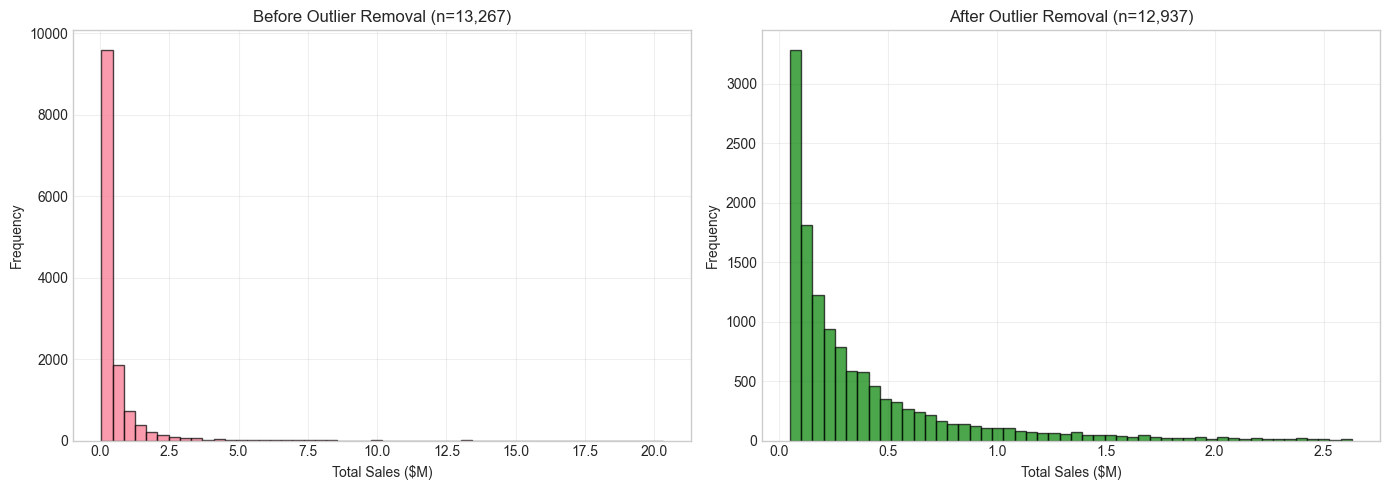


Distribution Statistics:
Before - Mean: $0.49M, Std: $0.93M
After  - Mean: $0.38M, Std: $0.44M


In [29]:
# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(df['total_sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Sales ($M)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Before Outlier Removal (n={len(df):,})')
axes[0].grid(alpha=0.3)

# After
axes[1].hist(df_clean['total_sales'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Total Sales ($M)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'After Outlier Removal (n={len(df_clean):,})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDistribution Statistics:")
print(f"Before - Mean: ${df['total_sales'].mean():.2f}M, Std: ${df['total_sales'].std():.2f}M")
print(f"After  - Mean: ${df_clean['total_sales'].mean():.2f}M, Std: ${df_clean['total_sales'].std():.2f}M")

---
## 9. Feature Scaling and Normalization

### 9.1 Compile Complete Feature Set

In [30]:
# Compile all engineered features
all_features = core_features + genre_features + platform_features + interaction_features

print("Complete Feature Set:")
print("="*80)
print(f"Total features engineered: {len(all_features)}")
print(f"  - Core features: {len(core_features)}")
print(f"  - Genre features: {len(genre_features)}")
print(f"  - Platform features: {len(platform_features)}")
print(f"  - Interaction features: {len(interaction_features)}")

# Verify all features exist
missing_features = [f for f in all_features if f not in df_clean.columns]
if missing_features:
    print(f"\nWARNING: Missing features: {missing_features}")
else:
    print("\nAll features present in dataframe.")

Complete Feature Set:
Total features engineered: 51
  - Core features: 17
  - Genre features: 14
  - Platform features: 10
  - Interaction features: 10

All features present in dataframe.


### 9.2 Prepare Feature Matrix

In [31]:
# Extract feature matrix
X = df_clean[all_features].copy()

# Replace infinities with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Handle missing values (impute with median)
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print("Imputing missing values with median:")
    for col in X.columns[X.isnull().any()]:
        median_val = X[col].median()
        null_count = X[col].isnull().sum()
        X[col] = X[col].fillna(median_val)
        print(f"  {col}: {null_count} values imputed with {median_val:.4f}")
else:
    print("No missing values detected.")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Data quality: {(1 - X.isnull().sum().sum()/(X.shape[0]*X.shape[1]))*100:.2f}% complete")

Imputing missing values with median:
  na_sales: 2387 values imputed with 0.1400
  jp_sales: 8700 values imputed with 0.0800
  pal_sales: 3221 values imputed with 0.0600
  other_sales: 1547 values imputed with 0.0200
  critic_score: 9554 values imputed with 0.7300
  game_age: 25 values imputed with 17.0000
  na_sales_ratio: 2387 values imputed with 0.6290
  jp_sales_ratio: 8700 values imputed with 0.6732
  pal_sales_ratio: 3221 values imputed with 0.2710
  other_sales_ratio: 1547 values imputed with 0.0830
  sales_concentration_hhi: 10974 values imputed with 0.3970
  genre_avg_quality: 31 values imputed with 0.7236
  platform_avg_quality: 151 values imputed with 0.7073
  quality_per_sales: 9554 values imputed with 1.9697
  sales_per_quality: 9554 values imputed with 0.4286
  sales_vs_quality_ratio: 9554 values imputed with 0.4286
  regional_balance: 10974 values imputed with 0.6030
  year_competition: 25 values imputed with 640.0000
  age_sales_product: 25 values imputed with 3.6800

F

### 9.3 Apply Robust Scaling

**Scaler:** RobustScaler  
**Rationale:** Less sensitive to outliers than StandardScaler, uses median and IQR.

In [32]:
# Initialize scaler
scaler = RobustScaler()

# Fit and transform
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=all_features, index=X.index)

print("Features scaled using RobustScaler.")
print(f"\nScaled data statistics:")
print(X_scaled.describe())

Features scaled using RobustScaler.

Scaled data statistics:
       total_sales   na_sales   jp_sales  pal_sales  other_sales  \
count   12937.0000 12937.0000 12937.0000 12937.0000   12937.0000   
mean        0.4610     0.4935     0.0204     0.6170       0.5880   
std         1.1779     1.5298     0.1104     1.8288       2.3337   
min        -0.4324    -0.8235    -0.0800    -0.6667      -0.6667   
25%        -0.2973    -0.3529     0.0000    -0.3333      -0.3333   
50%         0.0000     0.0000     0.0000     0.0000       0.0000   
75%         0.7027     0.6471     0.0000     0.6667       0.6667   
max         6.5405    12.7059     2.0500    19.2222      67.6667   

       critic_score   game_age  na_sales_ratio  jp_sales_ratio  \
count    12937.0000 12937.0000      12937.0000      12937.0000   
mean        -0.0062     0.1349         -0.0225         -0.0297   
std          0.0718     0.7775          0.7345          0.2396   
min         -0.6300    -1.5000         -2.3057         -0.6732

### 9.4 Feature Importance Analysis

Top 20 Features by Variance:
other_sales            5.4461
pal_sales              3.3446
na_sales               2.3403
quality_per_sales      2.0521
age_sales_product      1.6639
total_sales            1.3875
console_generation     1.1906
pub_genre_expertise    1.1881
other_sales_ratio      1.1823
platform_popularity    1.0787
pal_sales_ratio        1.0098
genre_avg_sales        0.9529
pub_avg_sales          0.7123
platform_genre_fit     0.6616
game_age               0.6045
platform_avg_quality   0.5715
na_sales_ratio         0.5395
dominant_region_id     0.5121
platform_avg_sales     0.4755
pub_game_count         0.3430
dtype: float64


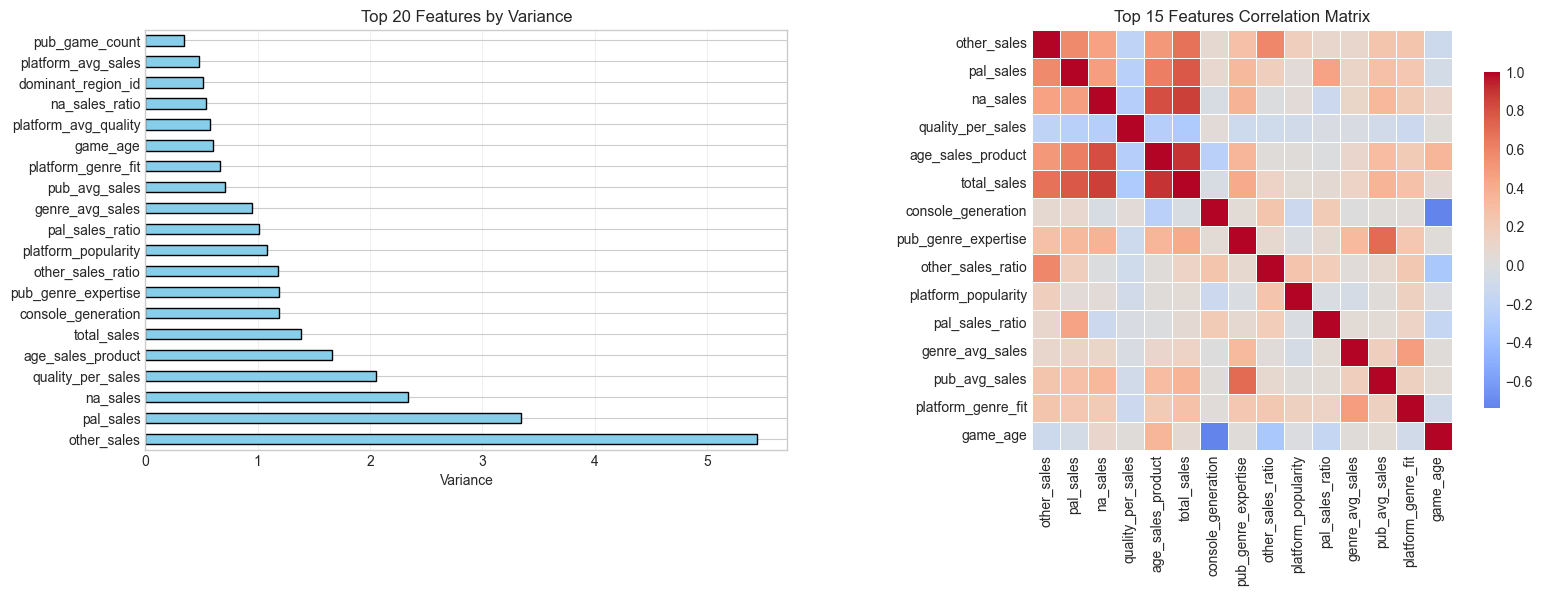


Visualization saved: 00_feature_analysis.png


In [33]:
# Calculate variance of each feature
feature_variance = X_scaled.var().sort_values(ascending=False)

print("Top 20 Features by Variance:")
print(feature_variance.head(20))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Variance plot
feature_variance.head(20).plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Variance')
axes[0].set_title('Top 20 Features by Variance')
axes[0].grid(axis='x', alpha=0.3)

# Correlation heatmap (top 15)
top_features = feature_variance.head(15).index
corr = X_scaled[top_features].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=axes[1], 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title('Top 15 Features Correlation Matrix')

plt.tight_layout()
plt.savefig('00_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved: 00_feature_analysis.png")

---
## 10. Feature Validation and Export

### 10.1 Final Data Quality Checks

In [34]:
print("Final Data Quality Report:")
print("="*80)
print(f"Final dataset size: {len(X_scaled):,} games")
print(f"Total features: {X_scaled.shape[1]}")
print(f"Missing values: {X_scaled.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(X_scaled.values).sum()}")
print(f"Data completeness: {(1 - X_scaled.isnull().sum().sum()/(X_scaled.shape[0]*X_scaled.shape[1]))*100:.2f}%")

# Check for constant features
constant_features = [col for col in X_scaled.columns if X_scaled[col].nunique() == 1]
if constant_features:
    print(f"\nWARNING: Constant features detected: {constant_features}")
else:
    print("\nNo constant features detected.")

# Feature value range
print(f"\nFeature value ranges:")
print(f"  Min: {X_scaled.min().min():.4f}")
print(f"  Max: {X_scaled.max().max():.4f}")
print(f"  Mean: {X_scaled.mean().mean():.4f}")
print(f"  Std: {X_scaled.std().mean():.4f}")

Final Data Quality Report:
Final dataset size: 12,937 games
Total features: 51
Missing values: 0
Infinite values: 0
Data completeness: 100.00%

No constant features detected.

Feature value ranges:
  Min: -4.0000
  Max: 67.6667
  Mean: 0.1329
  Std: 0.6191


### 10.2 Export Processed Data

In [35]:
# Export scaled features for clustering
X_scaled.to_csv('X_scaled_enhanced.csv', index=False)
print("Exported: X_scaled_enhanced.csv")

# Export full preprocessed dataframe
df_clean.to_csv('df_preprocessed_enhanced.csv', index=False)
print("Exported: df_preprocessed_enhanced.csv")

# Export feature list
with open('feature_list_enhanced.txt', 'w') as f:
    f.write('ENHANCED FEATURE SET\n')
    f.write('='*80 + '\n\n')
    f.write(f'Total features: {len(all_features)}\n\n')
    
    f.write('CORE FEATURES:\n')
    for feat in core_features:
        f.write(f'  - {feat}\n')
    
    f.write(f'\nGENRE FEATURES:\n')
    for feat in genre_features:
        f.write(f'  - {feat}\n')
    
    f.write(f'\nPLATFORM FEATURES:\n')
    for feat in platform_features:
        f.write(f'  - {feat}\n')
    
    f.write(f'\nINTERACTION FEATURES:\n')
    for feat in interaction_features:
        f.write(f'  - {feat}\n')

print("Exported: feature_list_enhanced.txt")

# Export metadata
metadata = {
    'n_games': len(df_clean),
    'n_features': len(all_features),
    'n_core_features': len(core_features),
    'n_genre_features': len(genre_features),
    'n_platform_features': len(platform_features),
    'n_interaction_features': len(interaction_features),
    'outlier_method': method_used,
    'scaler': 'RobustScaler',
    'retention_rate': len(df_clean)/original_size
}

with open('preprocessing_metadata.txt', 'w') as f:
    for key, value in metadata.items():
        f.write(f'{key}: {value}\n')

print("Exported: preprocessing_metadata.txt")

Exported: X_scaled_enhanced.csv
Exported: df_preprocessed_enhanced.csv
Exported: feature_list_enhanced.txt
Exported: preprocessing_metadata.txt


### 10.3 Preprocessing Summary

In [36]:
print("\n" + "="*80)
print("PREPROCESSING COMPLETE")
print("="*80)

print(f"""
Data Processing Summary:
  Original records:        {original_size:,}
  Final records:           {len(df_clean):,}
  Retention rate:          {len(df_clean)/original_size*100:.2f}%

Feature Engineering:
  Original features:       ~10 (raw data columns)
  Engineered features:     {len(all_features)}
  - Core features:         {len(core_features)}
  - Genre features:        {len(genre_features)}
  - Platform features:     {len(platform_features)}
  - Interaction features:  {len(interaction_features)}

Data Quality:
  Missing values:          {X_scaled.isnull().sum().sum()}
  Data completeness:       {(1 - X_scaled.isnull().sum().sum()/(X_scaled.shape[0]*X_scaled.shape[1]))*100:.2f}%
  Outlier removal:         {method_used} method
  Scaling method:          RobustScaler

Output Files:
  - X_scaled_enhanced.csv           (scaled features for clustering)
  - df_preprocessed_enhanced.csv    (full dataframe with all columns)
  - feature_list_enhanced.txt       (feature documentation)
  - preprocessing_metadata.txt      (processing parameters)
  - 00_feature_analysis.png         (feature importance visualization)


print("="*80)
print("Ready for clustering analysis.")
print("="*80)

SyntaxError: incomplete input (409043594.py, line 5)